In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [ ]:
from src.Data_preprocessing import load_data
df=load_data()

c:\Users\za813\anaconda3\envs\medical_cost\python.exe
2.2.3


<p style="color:red;font-size:50px">1-Nulls

In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

**not exist missing Values✅**

- no need to remove nulls function

<p style="color:red;font-size:50px">2-Duplicates

In [6]:
df.duplicated().sum()

1

In [7]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


**They might not be duplicates; they could actually be two different people.**

- - no need to remove duplicates function

<p style="color:red;font-size:50px"> 3-Outiers

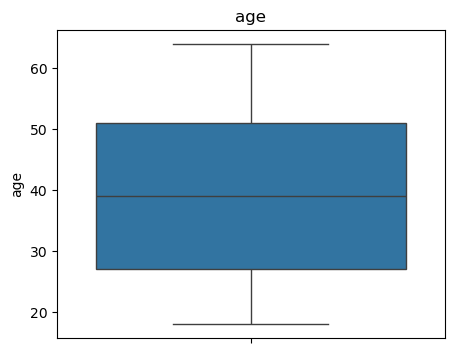

In [8]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df["age"])
plt.title("age")
plt.savefig("../Figures/boxplot of age.png")
plt.show()

**no outliers**

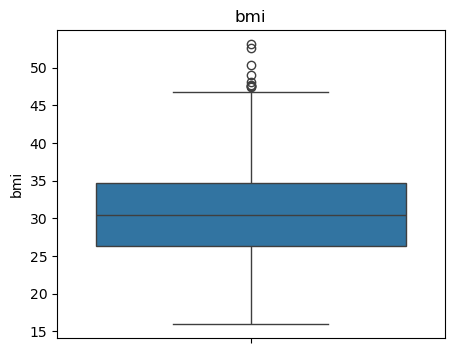

In [9]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df["bmi"])
plt.title("bmi")
plt.savefig("../Figures/boxplot of bmi.png")
plt.show()

In [10]:
Q1=df['bmi'].quantile(0.25)
Q3=df['bmi'].quantile(0.75)

IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df_outliers=df[(df['bmi']<lower)|(df['bmi']>upper)]
print(len(df_outliers))
print(len(df))
print((len(df_outliers)/len(df))*100)

9
1338
0.672645739910314


**Less than 1% of the data**

In [11]:
print(df_outliers)

      age     sex    bmi  children smoker     region      charges
116    58    male  49.06         0     no  southeast  11381.32540
286    46  female  48.07         2     no  northeast   9432.92530
401    47    male  47.52         1     no  southeast   8083.91980
543    54  female  47.41         0    yes  southeast  63770.42801
847    23    male  50.38         1     no  southeast   2438.05520
860    37  female  47.60         2    yes  southwest  46113.51100
1047   22    male  52.58         1    yes  southeast  44501.39820
1088   52    male  47.74         1     no  southeast   9748.91060
1317   18    male  53.13         0     no  southeast   1163.46270


In [12]:
df["bmi"].mean()

30.66339686098655

# Body Mass Index (BMI) Guide & Data Analysis


## 1. Calculation Formula

$$\text{BMI} = \frac{\text{Weight (kg)}}{\left(\text{Height (m)}\right)^2}$$



## 2. Categories, Classifications & Clinical Meanings

### **BMI Categories Overview**
| Category | BMI Range |
| :--- | :--- |
| **Underweight** | $< 18.5$ |
| **Normal / Healthy Weight** | $18.5 - 24.9$ |
| **Overweight** | $25.0 - 29.9$ |
| **Obesity (Class I)** | $30.0 - 34.9$ |
| **Obesity (Class II)** | $35.0 - 39.9$ |
| **Extreme / Severe Obesity (Class III)** | $\ge 40.0$ |



## 3. Data Preprocessing & Outlier Handling Note

* **Example Case:** $\text{BMI} = 53 \longrightarrow \text{(Severe / Extreme Obesity - Class III)}$

* **Is an extreme BMI value a Data Entry Error?**
  * **No, not necessarily.** High BMI values can represent realistic human measurements in clinical datasets.
  * *Example:* An individual with a height of **160 cm** ($1.60\text{ m}$) and a weight of **136 kg** produces:
    $$\text{BMI} = \frac{136}{1.60^2} = \frac{136}{2.56} \approx 53.12$$

* **Handling Decision:**
  * **Keep the record in the dataset (do not delete it).** It represents a valid, real-world extreme clinical observation rather than a corrupted entry or typo.

- - no need to remove outliers function